# F1 Lap Time Prediction — XGBoost Model
(Convert NaT to NaN or null in pit in / pit out laps)

**Circuit:** Bahrain Grand Prix (2022–2025)  
**Model:** XGBoost Regressor  
**Inputs:** Driver, LapNumber, Compound, TyreLife, Year  
**Target:** LapTime (seconds)  

Only drivers who maintained the same team across all 4 years are included:  
ALB (Williams), LEC (Ferrari), NOR (McLaren), RUS (Mercedes), VER (Red Bull)

### Year-over-Year Trend
A per-driver yearly improvement rate is computed so the model can extrapolate predictions to future years (e.g. 2026).

In [11]:
# ── Cell 1: Imports & Setup ──────────────────────────────────────────────────

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

In [12]:
# ── Cell 2: Data Loading ─────────────────────────────────────────────────────

files = sorted(glob.glob('datasets/Bahrain/*_Laps.csv'))
df_list = []

for f in files:
    temp_df = pd.read_csv(f)
    # Extract year from filename (e.g. '2022' from '2022_Bahrain_Laps.csv')
    year = int(os.path.basename(f).split('_')[0])
    temp_df['Year'] = year
    df_list.append(temp_df)
    print(f"Loaded {len(temp_df)} laps from {f}")

df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal laps loaded: {len(df)}")
df.head()

Loaded 1125 laps from datasets/Bahrain\2022_Bahrain_Laps.csv
Loaded 1056 laps from datasets/Bahrain\2023_Bahrain_Laps.csv
Loaded 1129 laps from datasets/Bahrain\2024_Bahrain_Laps.csv
Loaded 1128 laps from datasets/Bahrain\2025_Bahrain_Laps.csv

Total laps loaded: 4438


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Year
0,0 days 01:04:15.340000,VER,1,0 days 00:01:40.236000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.325000,...,Red Bull Racing,0 days 01:02:34.872000,NaT,1,2.0,NaN,NaN,False,False,2022
1,0 days 01:05:53.220000,VER,1,0 days 00:01:37.880000,2.0,1.0,NaT,NaT,0 days 00:00:31.285000,0 days 00:00:42.269000,...,Red Bull Racing,0 days 01:04:15.340000,NaT,1,2.0,NaN,NaN,False,True,2022
2,0 days 01:07:31.577000,VER,1,0 days 00:01:38.357000,3.0,1.0,NaT,NaT,0 days 00:00:31.499000,0 days 00:00:42.474000,...,Red Bull Racing,0 days 01:05:53.220000,NaT,1,2.0,NaN,NaN,False,True,2022
3,0 days 01:09:10.143000,VER,1,0 days 00:01:38.566000,4.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.674000,...,Red Bull Racing,0 days 01:07:31.577000,NaT,1,2.0,NaN,NaN,False,True,2022
4,0 days 01:10:49.020000,VER,1,0 days 00:01:38.877000,5.0,1.0,NaT,NaT,0 days 00:00:31.498000,0 days 00:00:42.854000,...,Red Bull Racing,0 days 01:09:10.143000,NaT,1,2.0,NaN,NaN,False,True,2022


In [13]:
# ── Cell 3: Data Cleaning ────────────────────────────────────────────────────

# --- Eligible drivers (same team across 2022-2025) ---
ELIGIBLE_DRIVERS = ['ALB', 'LEC', 'NOR', 'RUS', 'VER']

print(f"Starting rows: {len(df)}")

# 1. Keep only eligible drivers
df = df[df['Driver'].isin(ELIGIBLE_DRIVERS)].copy()
print(f"After filtering eligible drivers: {len(df)}")

# 2. Convert LapTime from timedelta string to seconds
df['LapTime'] = pd.to_timedelta(df['LapTime']).dt.total_seconds()

# 3. Drop rows where LapTime is NaN
df = df.dropna(subset=['LapTime'])
print(f"After dropping NaN LapTime: {len(df)}")

# 4. Keep only accurate laps
df = df[df['IsAccurate'] == True]
print(f"After keeping IsAccurate only: {len(df)}")

# 5. Remove pit-out laps (PitOutTime is not NaN)
df = df[df['PitOutTime'].isna()]
print(f"After removing pit-out laps: {len(df)}")

# 6. Remove pit-in laps (PitInTime is not NaN)
df = df[df['PitInTime'].isna()]
print(f"After removing pit-in laps: {len(df)}")

# 7. Remove first lap (LapNumber == 1)
df = df[df['LapNumber'] > 1]
print(f"After removing first laps: {len(df)}")

# 8. Green flag only (TrackStatus == 1)
df = df[df['TrackStatus'] == 1]
print(f"After green-flag filter: {len(df)}")

print(f"\n✅ Final clean dataset: {len(df)} laps")
print(f"Drivers: {sorted(df['Driver'].unique())}")
print(f"Years: {sorted(df['Year'].unique())}")
print(f"Compounds: {sorted(df['Compound'].unique())}")
df[['Driver', 'LapNumber', 'Compound', 'TyreLife', 'LapTime', 'Year']].head(10)

Starting rows: 4438
After filtering eligible drivers: 1117
After dropping NaN LapTime: 1108
After keeping IsAccurate only: 936
After removing pit-out laps: 0
After removing pit-in laps: 0
After removing first laps: 0
After green-flag filter: 0

✅ Final clean dataset: 0 laps
Drivers: []
Years: []
Compounds: []


,Driver,LapNumber,Compound,TyreLife,LapTime,Year


In [14]:
# ── Cell 4: Year-over-Year Improvement Analysis ──────────────────────────────
# Compute per-driver average lap time per year to understand the yearly trend.
# This will be used later to extrapolate predictions to future years.

yearly_avg = df.groupby(['Driver', 'Year'])['LapTime'].mean().reset_index()
yearly_avg.columns = ['Driver', 'Year', 'AvgLapTime']

# Compute per-driver improvement rate (slope) via linear regression on Year vs AvgLapTime
from scipy.stats import linregress

driver_trends = {}
print("Per-Driver Yearly Improvement (linear trend):")
print("=" * 65)
for driver in sorted(ELIGIBLE_DRIVERS):
    d = yearly_avg[yearly_avg['Driver'] == driver]
    slope, intercept, r_value, p_value, std_err = linregress(d['Year'], d['AvgLapTime'])
    driver_trends[driver] = {'slope': slope, 'intercept': intercept}
    direction = 'faster' if slope < 0 else 'slower'
    print(f"  {driver}: {slope:+.4f} s/year ({abs(slope):.2f}s {direction} each year, R²={r_value**2:.3f})")

# Overall average improvement
overall_avg = df.groupby('Year')['LapTime'].mean()
overall_slope, overall_intercept, _, _, _ = linregress(overall_avg.index, overall_avg.values)
print(f"\n  Overall: {overall_slope:+.4f} s/year")

# Plot the trends
fig, ax = plt.subplots(figsize=(9, 5))
for driver in sorted(ELIGIBLE_DRIVERS):
    d = yearly_avg[yearly_avg['Driver'] == driver]
    ax.plot(d['Year'], d['AvgLapTime'], 'o-', label=driver, linewidth=2, markersize=6)

ax.set_xlabel('Year')
ax.set_ylabel('Average Lap Time (s)')
ax.set_title('Average Lap Time by Year — Bahrain GP')
ax.legend()
ax.set_xticks([2022, 2023, 2024, 2025])
plt.tight_layout()
plt.show()

Per-Driver Yearly Improvement (linear trend):


ValueError: Inputs must not be empty.

In [ ]:
# ── Cell 5: Feature Encoding ─────────────────────────────────────────────────

# Label-encode Driver
le_driver = LabelEncoder()
df['Driver_encoded'] = le_driver.fit_transform(df['Driver'])

print("Driver encoding:")
for cls, lbl in zip(le_driver.classes_, range(len(le_driver.classes_))):
    print(f"  {cls} → {lbl}")

# One-hot encode Compound
compound_dummies = pd.get_dummies(df['Compound'], prefix='Compound')
df = pd.concat([df, compound_dummies], axis=1)

# Define feature columns and target — Year is now included
FEATURE_COLS = ['Driver_encoded', 'LapNumber', 'TyreLife', 'Year'] + \
               [c for c in df.columns if c.startswith('Compound_')]

TARGET_COL = 'LapTime'

print(f"\nFeatures: {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")
print(f"\nFeature matrix shape: {df[FEATURE_COLS].shape}")
df[FEATURE_COLS + [TARGET_COL]].describe()

Driver encoding:
  ALB → 0
  LEC → 1
  NOR → 2
  RUS → 3
  VER → 4

Features: ['Driver_encoded', 'LapNumber', 'TyreLife', 'Year', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT']
Target: LapTime

Feature matrix shape: (1090, 7)


,Driver_encoded,LapNumber,TyreLife,Year,LapTime
count,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000
mean,2.102752,32.922018,12.116514,2023.495413,81.955794
std,1.396734,18.883198,7.194031,1.067285,3.774220
min,0.000000,2.000000,2.000000,2022.000000,76.187000
25%,1.000000,17.000000,7.000000,2023.000000,79.499250
50%,2.000000,32.000000,11.000000,2023.000000,80.527500
75%,3.000000,49.000000,16.000000,2024.000000,82.376000
max,4.000000,66.000000,50.000000,2025.000000,93.007000


In [ ]:
# ── Cell 6: Train/Test Split ─────────────────────────────────────────────────

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 872 samples
Test set:     218 samples


In [ ]:
# ── Cell 7: XGBoost Training ─────────────────────────────────────────────────

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("✅ Model trained successfully!")
print(f"   Estimators: {model.n_estimators}")
print(f"   Max depth:  {model.max_depth}")
print(f"   Features:   {FEATURE_COLS}")

✅ Model trained successfully!
   Estimators: 200
   Max depth:  6
   Features:   ['Driver_encoded', 'LapNumber', 'TyreLife', 'Year', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT']


  Overall Test Set Metrics
  RMSE : 0.4881 s
  MAE  : 0.3337 s
  R²   : 0.9831

  Per-Driver Metrics
------------------------------------------------------------
  Driver       RMSE      MAE       R²  Samples
------------------------------------------------------------
  ALB        0.7566   0.4841   0.9671       36
  LEC        0.3095   0.2416   0.9826       42
  NOR        0.5043   0.3961   0.9718       40
  RUS        0.5038   0.3574   0.9837       55
  VER        0.2657   0.2147   0.9953       45


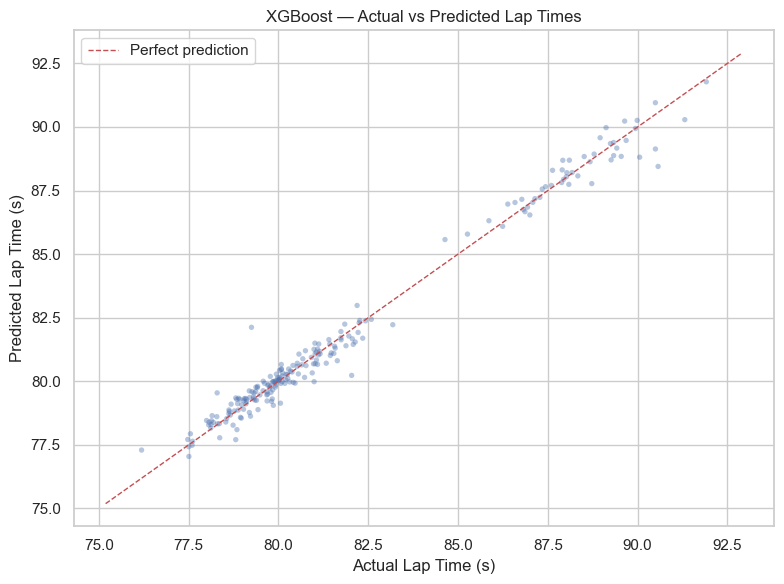

In [ ]:
# ── Cell 8: Evaluation ───────────────────────────────────────────────────────

y_pred = model.predict(X_test)

# Overall metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("="*50)
print("  Overall Test Set Metrics")
print("="*50)
print(f"  RMSE : {rmse:.4f} s")
print(f"  MAE  : {mae:.4f} s")
print(f"  R²   : {r2:.4f}")
print("="*50)

# Per-driver metrics
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred

print("\n  Per-Driver Metrics")
print("-"*60)
print(f"  {'Driver':<8} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Samples':>8}")
print("-"*60)

for code_idx in sorted(test_df['Driver_encoded'].unique()):
    driver_name = le_driver.inverse_transform([int(code_idx)])[0]
    mask = test_df['Driver_encoded'] == code_idx
    yt = test_df.loc[mask, 'y_true']
    yp = test_df.loc[mask, 'y_pred']
    d_rmse = np.sqrt(mean_squared_error(yt, yp))
    d_mae  = mean_absolute_error(yt, yp)
    d_r2   = r2_score(yt, yp) if len(yt) > 1 else float('nan')
    print(f"  {driver_name:<8} {d_rmse:>8.4f} {d_mae:>8.4f} {d_r2:>8.4f} {len(yt):>8}")

# Scatter plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=15, edgecolors='none')
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Lap Time (s)')
ax.set_ylabel('Predicted Lap Time (s)')
ax.set_title('XGBoost — Actual vs Predicted Lap Times')
ax.legend()
plt.tight_layout()
plt.show()

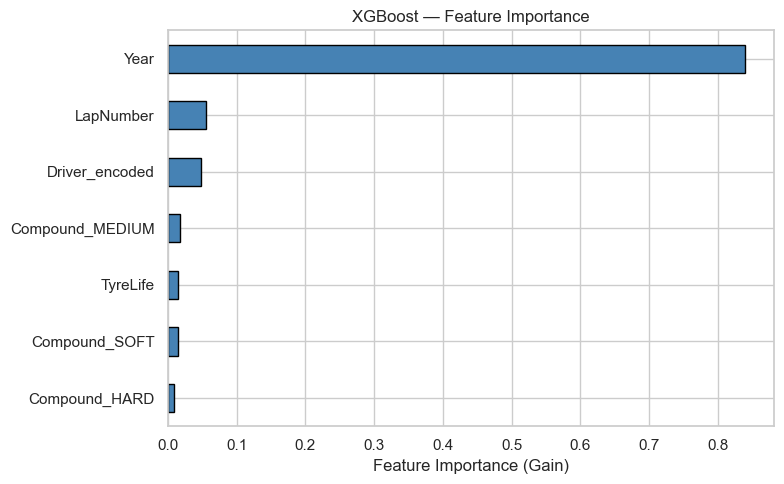


Feature importance values:
  Year                 0.8398
  LapNumber            0.0551
  Driver_encoded       0.0479
  Compound_MEDIUM      0.0180
  TyreLife             0.0155
  Compound_SOFT        0.0147
  Compound_HARD        0.0091


In [ ]:
# ── Cell 9: Feature Importance ───────────────────────────────────────────────

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

print("\nFeature importance values:")
for feat, imp in feat_imp[::-1].items():
    print(f"  {feat:<20s} {imp:.4f}")

In [ ]:
# ── Cell 10: Predicting for a Future Year ────────────────────────────────────
# XGBoost is tree-based and cannot extrapolate beyond training data range.
# To predict for a future year (e.g. 2026), we:
#   1. Use the model with Year=2025 (latest known year)
#   2. Apply the per-driver yearly improvement (linear trend) as an adjustment

def predict_future_year(model, driver, lap_number, compound, tyre_life, target_year,
                        le_driver=le_driver, driver_trends=driver_trends,
                        feature_cols=FEATURE_COLS, max_train_year=2025):
    """
    Predict lap time for a future year by combining:
      - XGBoost prediction at Year=max_train_year
      - Linear yearly improvement adjustment
    """
    driver_enc = le_driver.transform([driver])[0]
    
    # Build feature dict with Year = max training year
    features = {
        'Driver_encoded': driver_enc,
        'LapNumber': lap_number,
        'TyreLife': tyre_life,
        'Year': max_train_year,
    }
    # One-hot compound columns
    for col in feature_cols:
        if col.startswith('Compound_'):
            features[col] = 1 if col == f'Compound_{compound}' else 0
    
    X_input = pd.DataFrame([features])[feature_cols]
    base_pred = model.predict(X_input)[0]
    
    # Apply yearly improvement for the extra years
    years_ahead = target_year - max_train_year
    yearly_improvement = driver_trends[driver]['slope']  # negative = getting faster
    adjusted_pred = base_pred + (yearly_improvement * years_ahead)
    
    return adjusted_pred, base_pred, yearly_improvement


# --- Demo: Predict lap times for 2026 ---
print("Predicted lap times for 2026 Spain GP (mid-race, Lap 30, Medium tyres, TyreLife 10)")
print("=" * 75)
print(f"  {'Driver':<8} {'2025 Pred':>12} {'Yearly Δ':>12} {'2026 Pred':>12}")
print("-" * 75)

for driver in sorted(ELIGIBLE_DRIVERS):
    pred_2026, pred_2025, yearly_delta = predict_future_year(
        model, driver, lap_number=30, compound='MEDIUM', tyre_life=10, target_year=2026
    )
    print(f"  {driver:<8} {pred_2025:>10.3f} s {yearly_delta:>+10.3f} s {pred_2026:>10.3f} s")

Predicted lap times for 2026 Spain GP (mid-race, Lap 30, Medium tyres, TyreLife 10)
  Driver      2025 Pred     Yearly Δ    2026 Pred
---------------------------------------------------------------------------
  ALB          81.370 s     -2.394 s     78.976 s
  LEC          80.104 s     -2.388 s     77.716 s
  NOR          80.027 s     -2.704 s     77.324 s
  RUS          80.374 s     -2.276 s     78.097 s
  VER          79.812 s     -2.268 s     77.544 s
